In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('day.csv')


In [3]:
# 1. Convert cnt to binary demand: low (below median) vs high (at or above median)
median_cnt = df['cnt'].median()
df['demand'] = pd.cut(df['cnt'], bins=[-np.inf, median_cnt, np.inf],
                      labels=['low', 'high'], right=True)

# 2. Convert weathersit to ternary: 1=good, 2=moderate, 3&4=bad
df['weather_cat'] = df['weathersit'].map({1: 'good', 2: 'moderate', 3: 'bad', 4: 'bad'})

print("Median cnt:", median_cnt)
print("\nDemand distribution:\n", df['demand'].value_counts())
print("\nWeather category distribution:\n", df['weather_cat'].value_counts())


Median cnt: 4548.0

Demand distribution:
 demand
low     366
high    365
Name: count, dtype: int64

Weather category distribution:
 weather_cat
good        463
moderate    247
bad          21
Name: count, dtype: int64


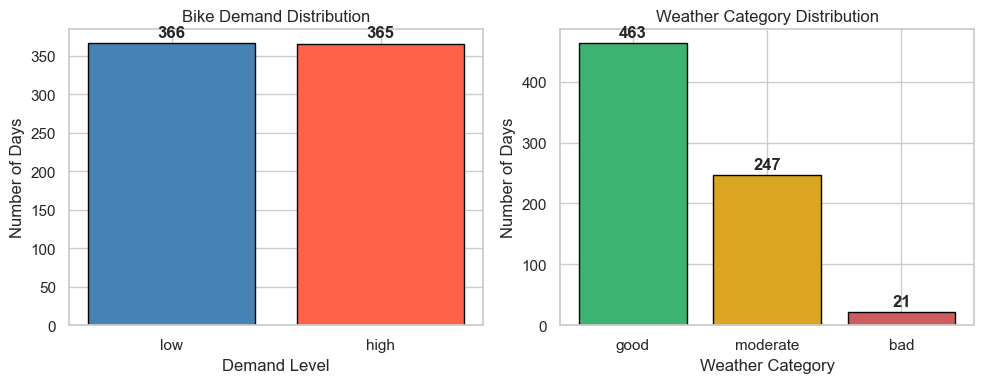

In [4]:
# Plot distributions of the two categorical variables
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Demand (low / high)
demand_counts = df['demand'].value_counts().reindex(['low', 'high'])
axes[0].bar(demand_counts.index, demand_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Bike Demand Distribution')
axes[0].set_xlabel('Demand Level')
axes[0].set_ylabel('Number of Days')
for bar, val in zip(axes[0].patches, demand_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Weather category (good / moderate / bad)
weather_order = ['good', 'moderate', 'bad']
weather_counts = df['weather_cat'].value_counts().reindex(weather_order)
axes[1].bar(weather_counts.index, weather_counts.values,
            color=['mediumseagreen', 'goldenrod', 'indianred'], edgecolor='black')
axes[1].set_title('Weather Category Distribution')
axes[1].set_xlabel('Weather Category')
axes[1].set_ylabel('Number of Days')
for bar, val in zip(axes[1].patches, weather_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## Why convert?
 A chi-square test of independence requires categorical variables.
  'cnt' is continuous, so it must be discretised into categories (low/high).
  'weathersit' uses integer codes 1-4; collapsing codes 3 and 4 into 'bad'
  is justified because 'heavy rain/ice' (4) is extremely rare (only a few days),



The Chi-square statistic measures how far observed counts differ from expected counts.

$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$

Where

$𝑂_{𝑖𝑗}$ = observed count  
$𝐸_{𝑖𝑗}$ = expected count = $\frac{Product \, of \, Marginal\, Counts}{Sample Size}$

In [5]:
# Chi-square test of independence: demand vs weather
contingency_table = pd.crosstab(df['demand'], df['weather_cat'])
print("Contingency table:\n", contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom (r-1)*(c-1)  : {dof}")
print(f"P-value              : {p_value:.4e}")
print(f"Expected frequencies:\n{expected}")
if p_value < 0.05:
    print("\nConclusion: Reject H0 — demand is NOT independent of weather (p < 0.05).")
else:
    print("\nConclusion: Fail to reject H0 — no significant evidence against independence (p >= 0.05).")


Contingency table:
 weather_cat  bad  good  moderate
demand                          
low           20   193       153
high           1   270        94

Chi-square statistic : 44.0879
Degrees of freedom (r-1)*(c-1)  : 2
P-value              : 2.6695e-10
Expected frequencies:
[[ 10.51436389 231.81668947 123.66894665]
 [ 10.48563611 231.18331053 123.33105335]]

Conclusion: Reject H0 — demand is NOT independent of weather (p < 0.05).


In [6]:
print(chi2_contingency(contingency_table))

Chi2ContingencyResult(statistic=np.float64(44.08792366696129), pvalue=np.float64(2.6694944140816527e-10), dof=2, expected_freq=array([[ 10.51436389, 231.81668947, 123.66894665],
       [ 10.48563611, 231.18331053, 123.33105335]]))


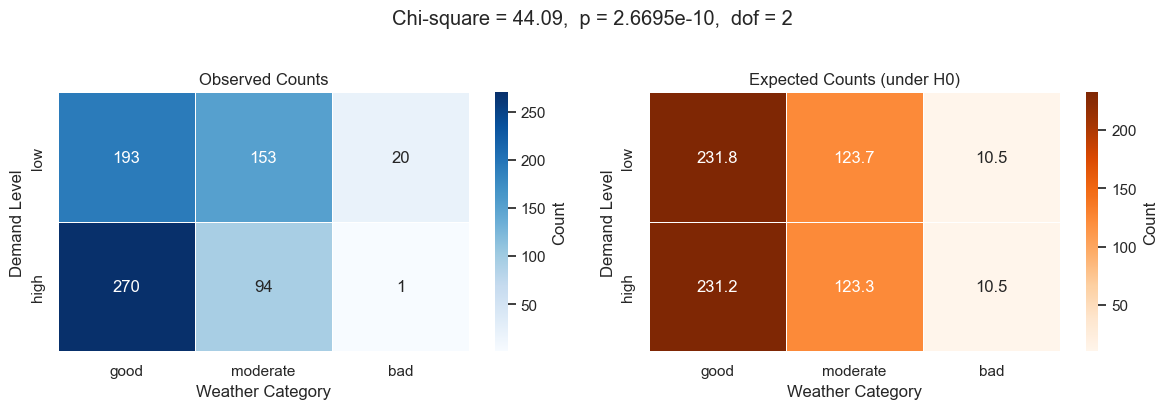

In [7]:
# Heatmap: observed vs expected counts side-by-side
weather_order = ['good', 'moderate', 'bad']
ct_ordered = contingency_table.reindex(columns=weather_order)
# expected is in the same column order as contingency_table (alphabetical: bad, good, moderate)
# so build expected_df using the original columns first, then reorder to match ct_ordered
expected_df = (pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
               .reindex(columns=weather_order))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(ct_ordered, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Observed Counts')
axes[0].set_xlabel('Weather Category')
axes[0].set_ylabel('Demand Level')

sns.heatmap(expected_df, annot=True, fmt='.1f', cmap='Oranges', linewidths=0.5,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Expected Counts (under H0)')
axes[1].set_xlabel('Weather Category')
axes[1].set_ylabel('Demand Level')

plt.suptitle(f'Chi-square = {chi2:.2f},  p = {p_value:.4e},  dof = {dof}', y=1.02)
plt.tight_layout()
plt.show()


Cramér’s V quantifies how strong the association is between two categorical variables

$$ V=\sqrt{\frac{\chi^2}{n(k-1)}} $$

Where:     
 $\chi^2$ = Chi-Square test statistic    
 n = total sample size    
 k = min(r,c)

Interpretation of Cramér's V:      
  0.00 - 0.10 : Very small effect     
  0.10 - 0.30 : small effect       
  0.30 - 0.50 : medium effect        
  0.50 - 1.00     : large effect         


In [8]:
n = contingency_table.values.sum()
r, c = contingency_table.shape          # rows, columns
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print(f"Cramér's V = {cramers_v:.4f}")
if cramers_v < 0.10:
    strength = "negligible"
elif cramers_v < 0.30:
    strength = "small"
elif cramers_v < 0.50:
    strength = "medium"
else:
    strength = "large"
print(f"Effect strength: {strength}")


Cramér's V = 0.2456
Effect strength: small


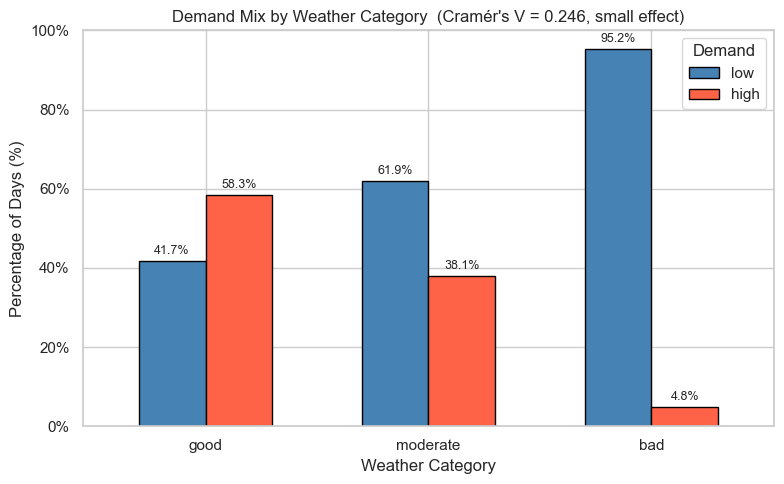

In [9]:
# Grouped bar chart: demand breakdown per weather category
weather_order = ['good', 'moderate', 'bad']
ct_pct = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100  # column %
ct_pct = ct_pct.reindex(columns=weather_order)

ax = ct_pct.T.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'tomato'],
                   edgecolor='black', width=0.6)
ax.set_title(f"Demand Mix by Weather Category  (Cramér's V = {cramers_v:.3f}, {strength} effect)")
ax.set_xlabel('Weather Category')
ax.set_ylabel('Percentage of Days (%)')
ax.set_xticklabels(weather_order, rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Demand', loc='upper right')

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [10]:
# import numpy as np
# import pandas as pd
# from scipy.stats import ttest_ind

# def run_welch_test(
#     df: pd.DataFrame,
#     temp_col: str = "temp",
#     tau: str = "mean",
#     target_col: str = "cnt",
#     alphas: tuple = (0.01, 0.05, 0.10),
# ):
#     tau_val = df[temp_col].mean() if tau == "mean" else df[temp_col].median()
    
#     low  = df.loc[df[temp_col] <= tau_val, target_col]
#     high = df.loc[df[temp_col] >  tau_val, target_col]
    
#     t_stat, p_val = ttest_ind(low, high, equal_var=False)
    
#     print(f"{'='*55}")
#     print(f"  temp_col : {temp_col}   |   tau ({tau}) = {tau_val:.4f}")
#     print(f"  H0: mean rentals are equal for low and high {temp_col}")
#     print(f"  H1: mean rentals differ between low and high {temp_col}")
#     print(f"  n_low={len(low)}, mean_low={low.mean():.2f}")
#     print(f"  n_high={len(high)}, mean_high={high.mean():.2f}")
#     print(f"  t-statistic = {t_stat:.4f}")
#     print(f"  p-value     = {p_val:.4e}")
#     print(f"  {'─'*45}")
#     for a in alphas:
#         decision = "Reject H0" if p_val < a else "Fail to reject H0"
#         print(f"  alpha={a:.2f}  =>  {decision}")
#     print(f"{'='*55}\n")
    
#     return {"tau_val": tau_val, "t_stat": t_stat, "p_val": p_val,
#             "mean_low": low.mean(), "mean_high": high.mean()}


# def run_all(df: pd.DataFrame, alphas: tuple = (0.01, 0.05, 0.10)):
#     results = {}
#     for temp_col in ["temp", "atemp"]:
#         for tau in ["mean", "median"]:
#             key = f"{temp_col}_{tau}"
#             print(f"\n>>> Part: temp_col={temp_col}, tau={tau}")
#             results[key] = run_welch_test(df, temp_col=temp_col, tau=tau, alphas=alphas)
    
#     print("\n>>> Which captures data better? (lower p-value = stronger evidence)")
#     for tau in ["mean", "median"]:
#         p_temp  = results[f"temp_{tau}"]["p_val"]
#         p_atemp = results[f"atemp_{tau}"]["p_val"]
#         better  = "temp" if p_temp < p_atemp else "atemp"
#         print(f"  tau={tau}: temp p={p_temp:.4e}, atemp p={p_atemp:.4e}  =>  '{better}' captures better")
    
#     return results

# results = run_all(df)